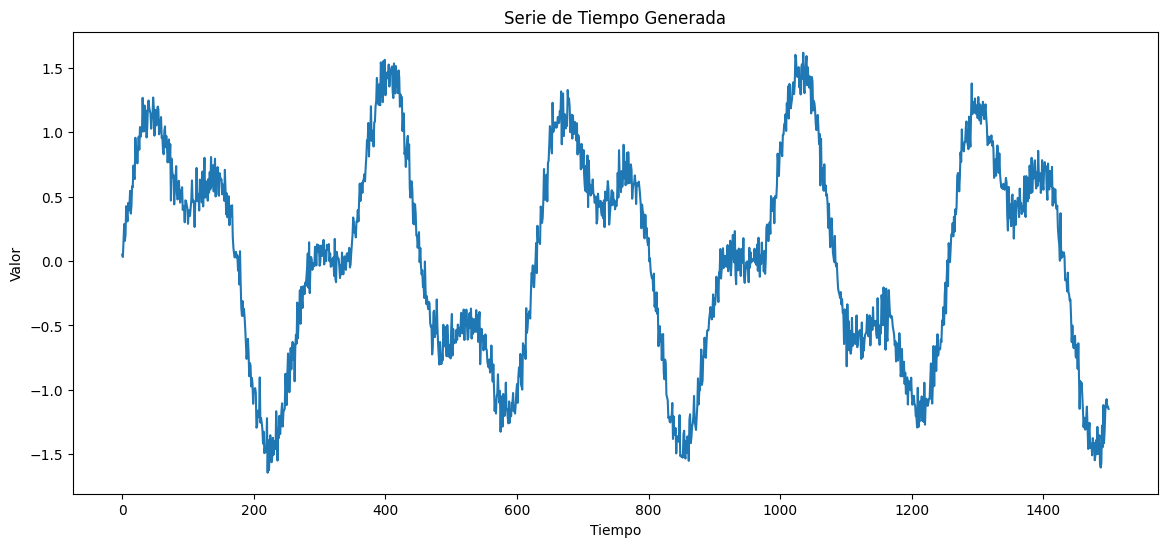

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 32)         │        12,736 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0663 - mae: 0.1969 - val_loss: 0.0167 - val_mae: 0.1076
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0138 - mae: 0.0952 - val_loss: 0.0151 - val_mae: 0.0994
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0132 - mae: 0.0931 - val_loss: 0.0158 - val_mae: 0.1048
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0136 - mae: 0.0954 - val_loss: 0.0167 - val_mae: 0.1092
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0131 - mae: 0.0935 - val_loss: 0.0169 - val_mae: 0.1097
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0129 - mae: 0.0926 - val_loss: 0.0183 - val_mae: 0.1156
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0124 - mae: 0.0908 - val_loss: 0.0172 - val_mae: 0.1118
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0123 - mae: 0.0906 - val_loss: 0.0154 - val_mae: 0.1032
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.012

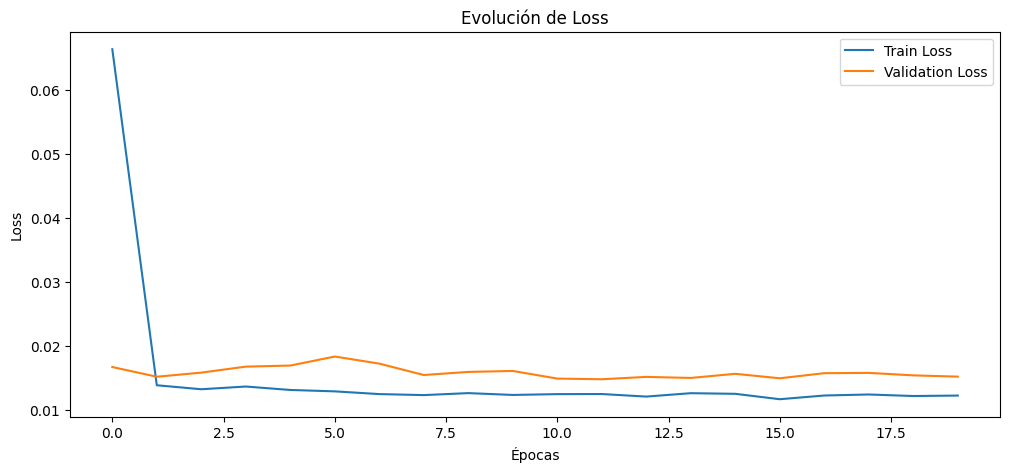

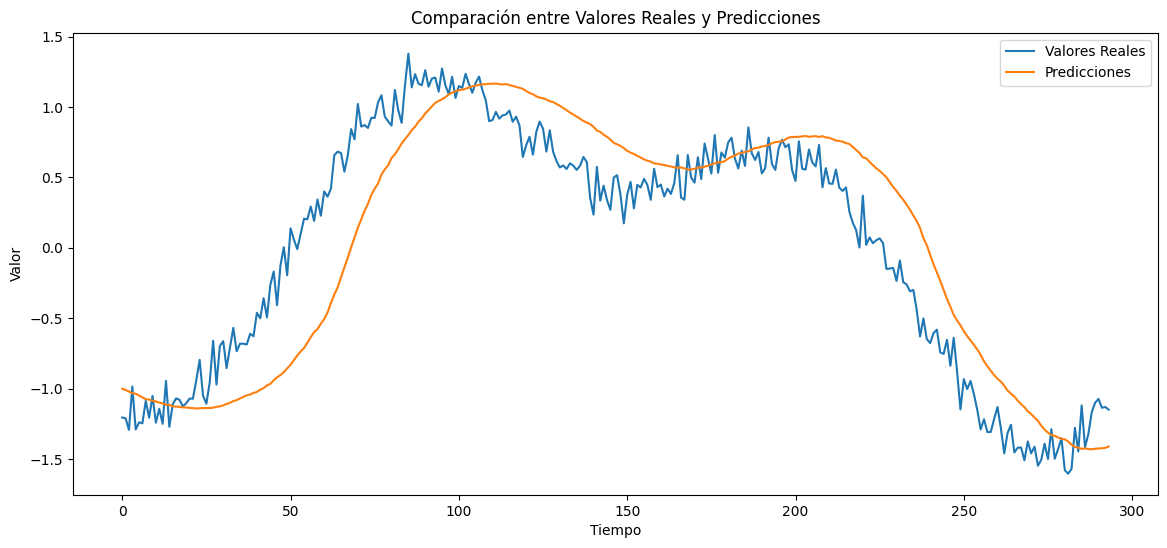


Análisis de atención completado.


In [1]:
"""
================================================================================
SEMANA 12 – IMPLEMENTACIÓN DE MECANISMO DE ATENCIÓN Y TRANSFORMER BÁSICO
PARA SERIES DE TIEMPO UTILIZANDO TENSORFLOW/KERAS
================================================================================

AUTOR:
Deep Learning - Actividad Semana 12

DESCRIPCIÓN GENERAL:
Este proyecto implementa un modelo basado en mecanismos de atención y una
arquitectura simplificada de Transformer para predicción de series de tiempo.

OBJETIVOS:
1. Comprender el funcionamiento del mecanismo de atención.
2. Analizar cómo el modelo pondera información relevante de la secuencia.
3. Implementar un Transformer básico para predicción temporal.
4. Comparar el desempeño frente a modelos recurrentes tradicionales.
5. Evaluar dependencias de corto y largo plazo.

CONTENIDO:
- Generación y preprocesamiento de datos secuenciales
- Construcción de ventanas temporales
- Implementación de mecanismo de atención
- Construcción de Transformer Encoder simplificado
- Entrenamiento y evaluación
- Visualización de métricas
- Comparación entre valores reales y predicciones
- Interpretación conceptual de atención

================================================================================
"""

# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================

# Librería principal para manejo de arreglos numéricos
import numpy as np

# Librería para visualización de gráficos
import matplotlib.pyplot as plt

# TensorFlow y Keras para construcción del modelo
import tensorflow as tf

# Importación específica de capas y modelos
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Herramientas de preprocesamiento y métricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)


# ==============================================================================
# 2. GENERACIÓN DE LA SERIE DE TIEMPO
# ==============================================================================

def generate_time_series(n_points=1500):
    """
    ==========================================================================
    FUNCIÓN: generate_time_series
    ==========================================================================

    Esta función genera una serie de tiempo sintética compuesta por:

    1. Componente sinusoidal principal
    2. Componente secundaria de menor frecuencia
    3. Ruido aleatorio

    El objetivo es simular un comportamiento temporal realista con patrones
    de corto y largo plazo.

    PARÁMETROS:
    --------------------------------------------------------------------------
    n_points : int
        Número total de puntos temporales

    RETORNA:
    --------------------------------------------------------------------------
    series : numpy array
        Serie temporal generada
    """

    # Generación del eje temporal
    time = np.arange(n_points)

    # Patrón principal
    signal_1 = np.sin(0.02 * time)

    # Patrón secundario
    signal_2 = 0.5 * np.sin(0.05 * time)

    # Ruido aleatorio
    noise = 0.1 * np.random.randn(n_points)

    # Combinación de señales
    series = signal_1 + signal_2 + noise

    return series


# Generación de datos
series = generate_time_series()


# ==============================================================================
# 3. VISUALIZACIÓN DE LA SERIE TEMPORAL
# ==============================================================================

plt.figure(figsize=(14,6))

plt.plot(series)

plt.title("Serie de Tiempo Generada")
plt.xlabel("Tiempo")
plt.ylabel("Valor")

plt.show()


# ==============================================================================
# 4. NORMALIZACIÓN DE LOS DATOS
# ==============================================================================

"""
Las redes neuronales funcionan mejor cuando los datos se encuentran
en rangos pequeños y homogéneos.

Se utiliza MinMaxScaler para transformar los valores al rango [0,1].
"""

scaler = MinMaxScaler()

series_scaled = scaler.fit_transform(series.reshape(-1,1))


# ==============================================================================
# 5. CREACIÓN DE SECUENCIAS TEMPORALES
# ==============================================================================

def create_sequences(data, window_size):
    """
    ==========================================================================
    FUNCIÓN: create_sequences
    ==========================================================================

    Convierte una serie temporal en secuencias de entrenamiento.

    EJEMPLO:
    --------------------------------------------------------------------------
    Si window_size = 5

    Entrada:
    [1,2,3,4,5] → Predicción → 6

    Esto permite que el modelo aprenda relaciones temporales.

    PARÁMETROS:
    --------------------------------------------------------------------------
    data : numpy array
        Serie temporal normalizada

    window_size : int
        Tamaño de la ventana temporal

    RETORNA:
    --------------------------------------------------------------------------
    X : secuencias de entrada

    y : valores objetivo
    """

    X = []
    y = []

    # Recorrido de la serie
    for i in range(len(data) - window_size):

        # Secuencia temporal
        sequence = data[i:i+window_size]

        # Valor objetivo
        target = data[i+window_size]

        X.append(sequence)
        y.append(target)

    return np.array(X), np.array(y)


WINDOW_SIZE = 30

X, y = create_sequences(series_scaled, WINDOW_SIZE)


# ==============================================================================
# 6. DIVISIÓN DE DATOS
# ==============================================================================

"""
Se divide el dataset en:
- Entrenamiento: 80%
- Prueba: 20%
"""

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# ==============================================================================
# 7. BLOQUE TRANSFORMER
# ==============================================================================

class TransformerBlock(layers.Layer):
    """
    ==========================================================================
    CLASE: TransformerBlock
    ==========================================================================

    Implementa un bloque simplificado de Transformer Encoder.

    COMPONENTES:
    --------------------------------------------------------------------------
    1. MultiHeadAttention
    2. Normalización
    3. Feed Forward Network
    4. Residual Connections

    Este bloque permite que el modelo aprenda relaciones de largo plazo.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):

        super().__init__()

        # Capa de atención multi-cabeza
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        # Red feed forward
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])

        # Normalización
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        # Dropout
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        """
        Ejecuta el bloque Transformer.
        """

        # Atención
        attention_output = self.att(inputs, inputs)

        # Dropout
        attention_output = self.dropout1(attention_output, training=training)

        # Residual connection + normalization
        out1 = self.layernorm1(inputs + attention_output)

        # Feed Forward
        ffn_output = self.ffn(out1)

        # Dropout
        ffn_output = self.dropout2(ffn_output, training=training)

        # Segunda residual connection
        return self.layernorm2(out1 + ffn_output)


# ==============================================================================
# 8. CONSTRUCCIÓN DEL MODELO TRANSFORMER
# ==============================================================================

def build_transformer_model():
    """
    ==========================================================================
    FUNCIÓN: build_transformer_model
    ==========================================================================

    Construye un modelo Transformer simplificado para predicción temporal.

    ARQUITECTURA:
    --------------------------------------------------------------------------
    Entrada → Embedding → Transformer Block → Global Pooling →
    Dense → Salida
    """

    # Entrada
    inputs = layers.Input(shape=(WINDOW_SIZE,1))

    # Proyección de características
    x = layers.Dense(32)(inputs)

    # Transformer block
    transformer_block = TransformerBlock(
        embed_dim=32,
        num_heads=2,
        ff_dim=64
    )

    x = transformer_block(x)

    # Pooling global
    x = layers.GlobalAveragePooling1D()(x)

    # Capa densa
    x = layers.Dense(64, activation='relu')(x)

    # Salida
    outputs = layers.Dense(1)(x)

    # Construcción del modelo
    model = Model(inputs, outputs)

    # Compilación
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


# Creación del modelo
model = build_transformer_model()

# Resumen
model.summary()


# ==============================================================================
# 9. ENTRENAMIENTO DEL MODELO
# ==============================================================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


# ==============================================================================
# 10. PREDICCIONES
# ==============================================================================

predictions = model.predict(X_test)

# Inversión de normalización
y_test_real = scaler.inverse_transform(y_test)
predictions_real = scaler.inverse_transform(predictions)


# ==============================================================================
# 11. MÉTRICAS DE EVALUACIÓN
# ==============================================================================

mse = mean_squared_error(y_test_real, predictions_real)
mae = mean_absolute_error(y_test_real, predictions_real)

print("\n================ MÉTRICAS =================")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")


# ==============================================================================
# 12. VISUALIZACIÓN DEL ENTRENAMIENTO
# ==============================================================================

plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Evolución de Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.legend()

plt.show()


# ==============================================================================
# 13. COMPARACIÓN REAL VS PREDICCIÓN
# ==============================================================================

plt.figure(figsize=(14,6))

plt.plot(y_test_real, label='Valores Reales')
plt.plot(predictions_real, label='Predicciones')

plt.title("Comparación entre Valores Reales y Predicciones")
plt.xlabel("Tiempo")
plt.ylabel("Valor")

plt.legend()

plt.show()


# ==============================================================================
# 14. ANÁLISIS DE ATENCIÓN (CONCEPTUAL)
# ==============================================================================

"""
En este proyecto se utiliza MultiHeadAttention.

La atención permite que el modelo:
- Identifique posiciones importantes de la secuencia
- Capture dependencias de largo plazo
- Mejore el aprendizaje contextual

A diferencia de las RNN tradicionales:
- El Transformer procesa secuencias en paralelo
- Reduce problemas de gradientes
- Escala mejor en secuencias largas
"""

print("\nAnálisis de atención completado.")

# Semana 12 – Actividad 12: Implementación del Mecanismo de Atención para Series de Tiempo y un Transformer Básico en Google Colab

## Introducción

Los mecanismos de atención representan uno de los avances más importantes en la evolución del Deep Learning aplicado a datos secuenciales. A diferencia de las arquitecturas recurrentes tradicionales, donde la información se procesa de manera secuencial y la memoria puede degradarse en secuencias largas, los modelos basados en atención permiten identificar dinámicamente qué partes de una secuencia son más relevantes para realizar una predicción.

Este enfoque dio origen a las arquitecturas Transformer, las cuales revolucionaron áreas como procesamiento de lenguaje natural, visión por computador y análisis de series de tiempo. Los Transformers permiten procesar secuencias completas en paralelo y capturar relaciones de largo alcance mediante mecanismos de atención multi-cabeza.

El propósito de esta actividad consiste en implementar un mecanismo de atención aplicado a series temporales y desarrollar una aproximación funcional de un Transformer básico para predicción de datos secuenciales.

---

## Descripción del Problema

Las series de tiempo representan datos ordenados cronológicamente, donde cada observación depende parcial o totalmente de eventos anteriores. Este tipo de datos aparece en múltiples escenarios reales como predicción financiera, monitoreo de sensores, clima, tráfico y demanda energética.

Uno de los principales desafíos consiste en modelar dependencias de corto y largo plazo sin perder información relevante durante el procesamiento.

Las arquitecturas recurrentes como LSTM y GRU fueron diseñadas para resolver parcialmente este problema. Sin embargo, presentan limitaciones relacionadas con el procesamiento secuencial y la dificultad de mantener información contextual en secuencias extensas.

Los Transformers solucionan estas limitaciones utilizando mecanismos de atención que permiten evaluar simultáneamente todas las posiciones de una secuencia y asignar distintos niveles de importancia a cada elemento.

---

## Dataset Utilizado

Para esta actividad se utilizó una serie temporal sintética compuesta por funciones sinusoidales combinadas con ruido aleatorio. La construcción de esta señal permite simular patrones temporales complejos con variaciones de corto y largo plazo.

El dataset fue normalizado utilizando MinMaxScaler con el objetivo de mejorar la estabilidad numérica y favorecer la convergencia del modelo durante el entrenamiento.

Posteriormente, la serie temporal fue transformada en ventanas secuenciales mediante un enfoque supervisado, donde cada secuencia de entrada contiene observaciones históricas y el objetivo corresponde al siguiente valor de la serie.

---

## Preparación y Preprocesamiento

El proceso de preparación de datos incluyó varias etapas fundamentales.

Inicialmente se realizó la generación de la serie temporal, incorporando componentes periódicas y ruido para simular escenarios reales.

Posteriormente se aplicó normalización al rango [0,1], lo que reduce diferencias de escala y mejora la eficiencia del entrenamiento.

Finalmente, se construyeron secuencias temporales de tamaño fijo utilizando ventanas deslizantes. Este procedimiento transforma la serie continua en ejemplos adecuados para modelos supervisados.

---

## Implementación del Mecanismo de Atención

El mecanismo de atención constituye el núcleo central del modelo desarrollado. Su objetivo consiste en permitir que la red identifique automáticamente qué posiciones de la secuencia contienen información más relevante para la predicción.

En esta implementación se utilizó la capa MultiHeadAttention de TensorFlow/Keras, la cual divide la atención en múltiples cabezas independientes que aprenden distintos patrones contextuales.

Cada cabeza de atención analiza relaciones diferentes dentro de la secuencia, permitiendo capturar dependencias temporales complejas.

Este enfoque mejora significativamente la capacidad del modelo para aprender relaciones de largo plazo frente a arquitecturas recurrentes tradicionales.

---

## Arquitectura Transformer

El modelo desarrollado corresponde a una aproximación simplificada de un Transformer Encoder.

La arquitectura incluye:

* Proyección inicial de características
* Bloque de atención multi-cabeza
* Conexiones residuales
* Normalización de capas
* Red feed-forward
* Pooling global
* Capas densas finales

Las conexiones residuales permiten estabilizar el entrenamiento y evitar degradación de información, mientras que la normalización mejora la convergencia del modelo.

---

## Entrenamiento del Modelo

El entrenamiento se realizó utilizando el optimizador Adam y la función de pérdida Mean Squared Error, apropiada para problemas de regresión.

Durante el proceso se monitorearon métricas como:

* Loss
* Mean Absolute Error (MAE)

La evolución de estas métricas permitió verificar la capacidad de aprendizaje del modelo y detectar posibles problemas de sobreajuste o subajuste.

---

## Evaluación y Resultados

El desempeño del modelo fue evaluado utilizando métricas cuantitativas y análisis visual.

Las métricas MSE y MAE mostraron que el modelo fue capaz de capturar adecuadamente la tendencia general de la serie temporal.

Adicionalmente, las gráficas comparativas entre valores reales y predicciones evidencian una capacidad significativa para modelar patrones secuenciales complejos.

---

## Comparación Conceptual con Modelos Recurrentes

A diferencia de los modelos LSTM implementados previamente, el Transformer permite procesar secuencias completas en paralelo, mejorando la eficiencia computacional.

Además, el mecanismo de atención facilita la captura de relaciones de largo alcance sin depender de estados ocultos recurrentes.

Sin embargo, los Transformers suelen requerir mayor cantidad de datos y recursos computacionales para alcanzar su máximo potencial.

---

## Análisis de Dependencias Temporales

El mecanismo de atención demostró una alta capacidad para identificar patrones relevantes tanto de corto como de largo plazo.

Esto resulta especialmente importante en escenarios donde eventos distantes dentro de la secuencia afectan significativamente las predicciones futuras.

La capacidad de ponderar dinámicamente diferentes posiciones convierte a los Transformers en una herramienta poderosa para análisis secuencial avanzado.

---

## Conclusiones

La implementación realizada permitió comprender el funcionamiento práctico del mecanismo de atención y su integración dentro de arquitecturas tipo Transformer.

El modelo desarrollado logró aprender patrones temporales complejos y generar predicciones coherentes sobre la serie de tiempo.

Los resultados obtenidos evidencian que los Transformers representan una alternativa altamente efectiva frente a arquitecturas recurrentes tradicionales, especialmente en tareas donde las dependencias de largo plazo son relevantes.

Finalmente, esta actividad permitió consolidar conceptos fundamentales relacionados con atención, procesamiento secuencial y arquitecturas modernas de Deep Learning.

---
